## Chains in LangGraph
Here we will be covering 4 concepts
- How to integrate chat message in graph
- how to integrate chat models
- how to bind tools with the LLM chat models
- how to execute tool call in graph

In [3]:
from dotenv import load_dotenv
load_dotenv()

import os
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
load_dotenv(override=True)


True

### Chat Message

In [4]:
from langchain_core.messages import AIMessage, HumanMessage
from pprint import PrettyPrinter
messages=[AIMessage(content="What you want to know?",name="LLMModel")]
messages.append(HumanMessage(content="What is the capital of France?",name="User"))
messages.append(AIMessage(content="The capital of France is Paris.",name="LLMModel"))
messages.append(HumanMessage(content="What is the population of Paris?",name="User"))
for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

What you want to know?
================================ Human Message =================================
Name: User

What is the capital of France?
================================== Ai Message ==================================
Name: LLMModel

The capital of France is Paris.
================================ Human Message =================================
Name: User

What is the population of Paris?


In [5]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(
    model="qwen/qwen3-next-80b-a3b-instruct:free",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)

d:\RAG\Demo Proj\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Chat Model

In [6]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI

os.environ.pop("OPENROUTER_API_KEY", None)
load_dotenv(override=True)

api_key = os.getenv("OPENROUTER_API_KEY")
assert api_key, "OPENROUTER_API_KEY not loaded"

llm = ChatOpenAI(
    model="nvidia/nemotron-3-nano-30b-a3b:free",
    api_key=api_key,
    base_url="https://openrouter.ai/api/v1",
)


In [7]:
llm.invoke(messages)

AIMessage(content='Parisproper (the city limits, also called **Paris intra‑muros**) has a population of roughly **2.1\u202fmillion people** as of the most recent estimates (2023‑2024).  \n\nIf you consider the larger **Île‑de‑France metropolitan region**, the population rises to about **12\u202fmillion** people, making it one of the biggest urban agglomerations in Europe.\n\n**Sources & recent figures**\n\n| Area | Approx. Population (2023‑2024 estimate) |\n|------|------------------------------------------|\n| Paris (city proper) | 2,165,000 |\n| Greater Paris (Île‑de‑France) | 12,200,000 |\n\nThese numbers come from the French **INSEE** (Institut National de la Statistique et des Études Économiques) and are consistent with the latest releases from the **Paris Region Institute for Economic Development (IAU‑Paris)** and the **United Nations World Urbanization Prospects** revision.\n\n*Note:* Population numbers can fluctuate slightly from year to year due to migration, births, deaths, a

### Tools
- Tools are the components which are used to connect external elements with the LLM model


In [34]:
## addition function tool call
def add(a:int,b:int)->int:
    """Add two integers and return the sum."""
    return a+b

In [8]:
llm

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x00000289623A3C50>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000289625D0050>, root_client=<openai.OpenAI object at 0x00000289623A39D0>, root_async_client=<openai.AsyncOpenAI object at 0x00000289623A3D90>, model_name='nvidia/nemotron-3-nano-30b-a3b:free', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://openrouter.ai/api/v1')

In [12]:
tool_call=llm.bind_tools([add])
tools=tool_call.invoke([HumanMessage(content="What is the sum of 5 and 7?",name="User")])
print(tools)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 157, 'prompt_tokens': 293, 'total_tokens': 450, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 130, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'nvidia/nemotron-3-nano-30b-a3b:free', 'system_fingerprint': None, 'id': 'gen-1774943395-dqTck91SmiP7dP5dGHmx', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d42de-e89f-70b1-a051-ec3a04e06a75-0' tool_calls=[{'name': 'add', 'args': {'a': 5, 'b': 7}, 'id': 'call_3d87f33d132a4570afbb2a6e', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_t

In [13]:
tools.tool_calls

[{'name': 'add',
  'args': {'a': 5, 'b': 7},
  'id': 'call_3d87f33d132a4570afbb2a6e',
  'type': 'tool_call'}]

In [14]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
class State(TypedDict):
    messages:list[AnyMessage]

- We all know that based on nodes state updates
: Here Reducer came into picture
### Reducer
A reducer in LangGraph is the rule for how state updates get merged into the graph state.

#### Why it exists:

- Multiple nodes can write to the same state key.
- LangGraph needs to know whether to overwrite, append, combine, or otherwise merge those values.
#### Simple mental model:

- State key = shared variable
- Reducer = merge strategy for that variable

In [15]:
from langgraph.graph.message import add_messages
from typing import Annotated
class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

In [16]:
def llm_tool(state:State):
    return {"messages": tool_call.invoke(state["messages"])}


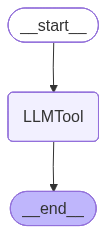

In [21]:
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display
builder=StateGraph(State)
builder.add_node("LLMTool", llm_tool)
builder.add_edge(START,"LLMTool")
builder.add_edge("LLMTool",END)
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
messages=graph.invoke({"messages":"What is the sum of 5 and 7?"})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is the sum of 5 and 7?
================================== Ai Message ==================================
Tool Calls:
  add (call_8b6030377a4742b49eaaccae)
 Call ID: call_8b6030377a4742b49eaaccae
  Args:
    a: 5
    b: 7


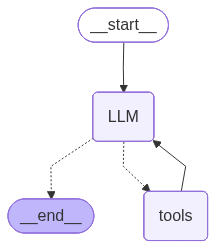

In [39]:
from langgraph.prebuilt import ToolNode, tools_condition
builder=StateGraph(State)
builder.add_node("LLM",llm_tool)
builder.add_node("tools", ToolNode([add]))
builder.add_edge(START,"LLM")
builder.add_conditional_edges(
    "LLM",
    tools_condition
)
builder.add_edge("tools","LLM")
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
messages=graph.invoke({"messages":"Addition of 2 and 3?"})
for message in messages["messages"]:
    message.pretty_print()  

================================ Human Message =================================

Addition of 2 and 3?
================================== Ai Message ==================================
Tool Calls:
  add (call_9c6782c56f3a4ab0b841a5c1)
 Call ID: call_9c6782c56f3a4ab0b841a5c1
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: add

5
================================== Ai Message ==================================

The sum of2 and 3 is **5**. Let me know if you'd like to perform another calculation!


In [41]:
messages=graph.invoke({"messages":"What is Quantum Computing?"})
for message in messages["messages"]:
    message.pretty_print()  

================================ Human Message =================================

What is Quantum Computing?
================================== Ai Message ==================================

Quantum computing is afield that leverages principles of quantum mechanics to perform computations. It uses quantum bits (qubits) that can exist in superposition and entanglement states, enabling certain problems to be solved more efficiently than classical computers. However, I currently don't have access to tools or resources to provide a detailed explanation of this complex topic. Would you like clarification on a specific aspect, or should I suggest alternative ways to learn more?
